## **PART A**
##### **Step 01** : Environment Setup & Week 3 Data Pipeline
##### **Step 02** : Feature Selection & Target Preparation
##### **Step 03** : Train-Test Split & Feature Scaling
##### **Step 04** : Create Evaluation & Visualization Utility Functions
##### **Step 05** : Train & Evaluate Baseline Linear Regression Model

#***STEP 01***

In [1]:
!pip install scikit-learn seaborn scipy joblib -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, boxcox
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    learning_curve
)
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PolynomialFeatures
)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.feature_selection import VarianceThreshold
import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/train.csv')
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
# Standardize Column Names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(' ', '_')
)
# Separate Numerical & Categorical Columns
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = df.select_dtypes(
    include='object'
).columns

# Fill Missing Numerical Values with Median
for col in numerical_cols:
    df[col].fillna(
        df[col].median(),
        inplace=True
    )
# Fill Missing Categorical Values with Mode
for col in categorical_cols:
    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )
# Apply Quality Encoding
quality_map = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1
}
quality_columns = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual',
    'GarageCond'
]
for col in quality_columns:
    if col in df.columns:
        df[col] = (
            df[col]
            .map(quality_map)
            .fillna(0)
        )
# Frequency Encoding — Neighborhood
if 'Neighborhood' in df.columns:

    neighborhood_freq = (
        df['Neighborhood']
        .value_counts(normalize=True)
    )

    df['Neighborhood'] = (
        df['Neighborhood']
        .map(neighborhood_freq)
    )

# One-Hot Encoding for Remaining Nominal Columns
remaining_cat_cols = df.select_dtypes(
    include='object'
).columns
df = pd.get_dummies(
    df,
    columns=remaining_cat_cols,
    drop_first=True
)

print("\nFinal Dataset Shape:")
print(df.shape)
print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())


Final Dataset Shape:
(1460, 200)

Remaining Missing Values:
0


#***STEP 02***

In [5]:
y_original = df['SalePrice']

# Select Top 20 Correlated Features
correlation_with_target = (
    df.corr()['SalePrice']
    .abs()
    .sort_values(ascending=False)
)
top_features = (
    correlation_with_target
    .drop(['SalePrice'], errors='ignore')
    .drop(['PricePerSF'], errors='ignore')
    .head(20)
    .index
    .tolist()
)
print("Top 20 Features Selected:\n")
for i, feature in enumerate(top_features, start=1):
    print(f"{i}. {feature}")

skew_before = df['SalePrice'].skew()
y = np.log1p(df['SalePrice'])

skew_after = y.skew()

# Feature Matrix
X = df[top_features]

print("\nTarget Skewness Before Log Transform:")
print(round(skew_before, 4))

print("\nTarget Skewness After Log Transform:")
print(round(skew_after, 4))

print("\nFeature Matrix Shape (X):")
print(X.shape)

print("\nTarget Vector Shape (y):")
print(y.shape)

Top 20 Features Selected:

1. OverallQual
2. GrLivArea
3. ExterQual
4. KitchenQual
5. BsmtQual
6. GarageCars
7. GarageArea
8. TotalBsmtSF
9. 1stFlrSF
10. FullBath
11. TotRmsAbvGrd
12. YearBuilt
13. GarageFinish_Unf
14. YearRemodAdd
15. Foundation_PConc
16. MasVnrArea
17. Fireplaces
18. GarageYrBlt
19. BsmtFinType1_GLQ
20. HeatingQC

Target Skewness Before Log Transform:
1.8829

Target Skewness After Log Transform:
0.1213

Feature Matrix Shape (X):
(1460, 20)

Target Vector Shape (y):
(1460,)


#***STEP 03***

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

# Apply StandardScaler
scaler = StandardScaler()

# Fit ONLY on Training Data
X_train_scaled = scaler.fit_transform(X_train)

# Transform Testing Data
X_test_scaled = scaler.transform(X_test)

# Convert Back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

# Verify Scaling Statistics
print("\nTraining Data Mean:")
print(X_train_scaled.mean().round(2).head())
print("\nTraining Data Standard Deviation:")
print(X_train_scaled.std().round(2).head())
print("\nTesting Data Mean:")
print(X_test_scaled.mean().round(2).head())
print("\nTesting Data Standard Deviation:")
print(X_test_scaled.std().round(2).head())

X_train Shape: (1168, 20)
X_test Shape : (292, 20)
y_train Shape: (1168,)
y_test Shape : (292,)

Training Data Mean:
OverallQual   -0.0
GrLivArea     -0.0
ExterQual      0.0
KitchenQual    0.0
BsmtQual       0.0
dtype: float64

Training Data Standard Deviation:
OverallQual    1.0
GrLivArea      1.0
ExterQual      1.0
KitchenQual    1.0
BsmtQual       1.0
dtype: float64

Testing Data Mean:
OverallQual   -0.08
GrLivArea     -0.11
ExterQual      0.01
KitchenQual    0.04
BsmtQual       0.01
dtype: float64

Testing Data Standard Deviation:
OverallQual    1.05
GrLivArea      1.01
ExterQual      1.00
KitchenQual    1.02
BsmtQual       0.99
dtype: float64


The training data has mean values close to 0 and standard deviation values close to 1 because the scaler was fitted directly on the training set. The testing data does not have exact mean 0 and standard deviation 1 because it was transformed using the statistics learned from the training data instead of its own statistics. This prevents data leakage and ensures a fair machine learning evaluation process.

#***STEP 04***

In [7]:
from typing import Dict

# Function - Model Evaluation
def evaluate_model(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    n_features: int
) -> Dict[str, float]:

    """
    Evaluates a regression model using multiple performance metrics.

    Parameters:
    y_true : pd.Series
        Actual target values.
    y_pred : np.ndarray
        Predicted target values.
    model_name : str
        Name of the regression model.
    n_features : int
        Number of input features used in the model.

    Returns:
    Dict[str, float]
        Dictionary containing regression evaluation metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adjusted_r2 = (
        1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    )
    mape = (
        np.mean(
            np.abs((y_true - y_pred) / y_true)
        ) * 100
    )
    results = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'Adjusted_R2': adjusted_r2,
        'MAPE': mape
    }
    print(f"\n{'='*50}")
    print(f"{model_name} Evaluation Metrics")
    print(f"{'='*50}")
    print(f"MAE          : {mae:.4f}")
    print(f"MSE          : {mse:.4f}")
    print(f"RMSE         : {rmse:.4f}")
    print(f"R² Score     : {r2:.4f}")
    print(f"Adjusted R²  : {adjusted_r2:.4f}")
    print(f"MAPE         : {mape:.2f}%")

    return results

In [8]:
# Function - Actual vs Predicted Plot
def plot_actual_vs_predicted(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str
) -> None:
    """
    Creates a scatter plot comparing actual and predicted values.

    Parameters:
    y_true : pd.Series
        Actual target values.
    y_pred : np.ndarray
        Predicted target values.
    model_name : str
        Name of the regression model.

    Returns:
    None
    """
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )
    plt.figure(figsize=(8, 6))
    plt.scatter(
        y_true,
        y_pred,
        alpha=0.7,
        color='royalblue'
    )
    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color='red',
        linestyle='--',
        linewidth=2
    )
    plt.title(
        f'{model_name} — Actual vs Predicted',
        fontsize=14
    )
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.text(
        0.05,
        0.95,
        f'R² = {r2:.4f}\nRMSE = {rmse:.4f}',
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.8
        )
    )
    plt.grid(alpha=0.3)
    plt.show()

#***STEP 05***

In [9]:
# Train Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(
    X_train_scaled,
    y_train
)
# Training Predictions
y_train_pred = linear_model.predict(X_train_scaled)
# Testing Predictions
y_test_pred = linear_model.predict(X_test_scaled)

In [10]:
# Evaluate Training Performance
train_results = evaluate_model(
    y_train,
    y_train_pred,
    "Linear Regression — Training",
    X_train_scaled.shape[1]
)
# Evaluate Testing Performance
test_results = evaluate_model(
    y_test,
    y_test_pred,
    "Linear Regression — Testing",
    X_test_scaled.shape[1]
)


Linear Regression — Training Evaluation Metrics
MAE          : 0.1087
MSE          : 0.0250
RMSE         : 0.1581
R² Score     : 0.8360
Adjusted R²  : 0.8331
MAPE         : 0.91%

Linear Regression — Testing Evaluation Metrics
MAE          : 0.1185
MSE          : 0.0273
RMSE         : 0.1652
R² Score     : 0.8537
Adjusted R²  : 0.8429
MAPE         : 1.00%


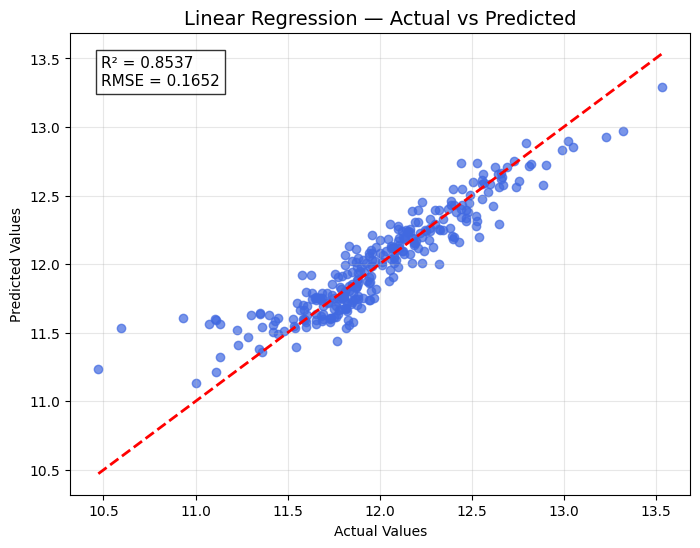

In [11]:
# Actual vs Predicted Plot
plot_actual_vs_predicted(
    y_test,
    y_test_pred,
    "Linear Regression"
)

In [12]:
# Coefficient Analysis
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linear_model.coef_
})
# Absolute Importance
coef_df['Absolute_Coefficient'] = (
    coef_df['Coefficient'].abs()
)
# Top 15 Features
top_15_features = (
    coef_df
    .sort_values(
        by='Absolute_Coefficient',
        ascending=False
    )
    .head(15)
)
# Display Table
print(top_15_features)

             Feature  Coefficient  Absolute_Coefficient
0        OverallQual     0.095787              0.095787
1          GrLivArea     0.080856              0.080856
11         YearBuilt     0.048946              0.048946
16        Fireplaces     0.044639              0.044639
5         GarageCars     0.042753              0.042753
13      YearRemodAdd     0.037216              0.037216
17       GarageYrBlt    -0.033055              0.033055
4           BsmtQual     0.027194              0.027194
6         GarageArea     0.026632              0.026632
7        TotalBsmtSF     0.025836              0.025836
10      TotRmsAbvGrd     0.025341              0.025341
12  GarageFinish_Unf    -0.022941              0.022941
3        KitchenQual     0.022143              0.022143
18  BsmtFinType1_GLQ     0.021346              0.021346
19         HeatingQC     0.019720              0.019720


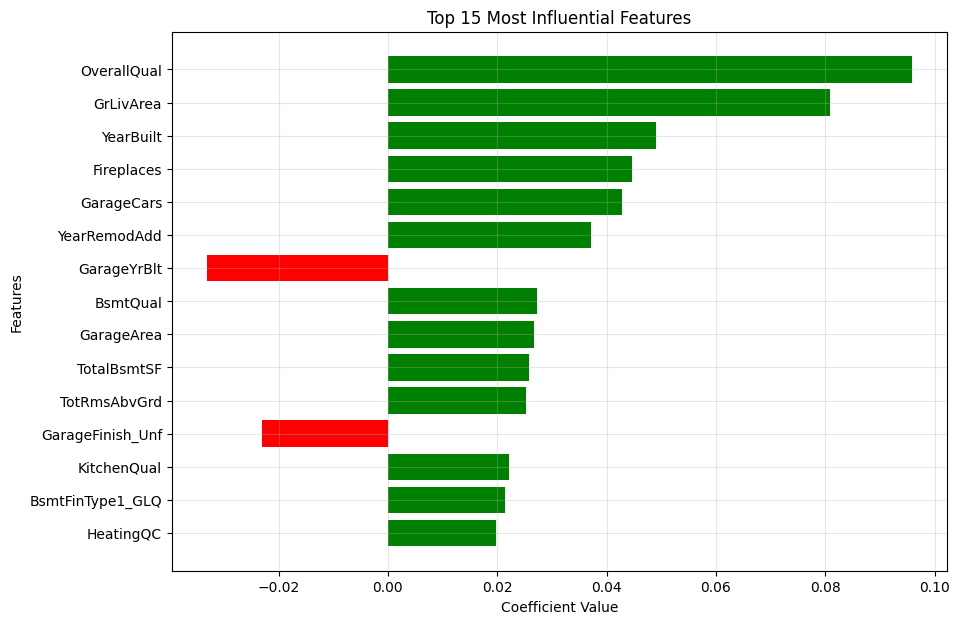

In [13]:
# Visualize Top 15 Influential Features

# Colors Based on Coefficient Sign
colors = [
    'green' if coef > 0 else 'red'
    for coef in top_15_features['Coefficient']
]
# Plot
plt.figure(figsize=(10, 7))
plt.barh(
    top_15_features['Feature'],
    top_15_features['Coefficient'],
    color=colors
)
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.title('Top 15 Most Influential Features')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.show()

The training and testing R² scores are relatively similar, indicating that the model generalizes reasonably well on unseen data. The small gap between train and test R² suggests limited overfitting. The feature with the strongest positive impact on predicted house price was `OverallQual` because it had the highest positive coefficient value in the model.

## **PART B**
##### **Step 06** : Polynomial Regression — Degree Comparison
##### **Step 07** : Ridge Regression — Alpha Exploration
##### **Step 08** : Lasso Regression — Feature Elimination Analysis
##### **Step 09** : ElasticNet — l1_ratio Exploration
##### **Step 10** : Polynomial + Ridge Pipeline — Best Combined Model
##### **Step 11** : Model Comparison Table — All 5 Models

#***STEP 06***

In [14]:
# Store Results
poly_results = []
# Polynomial Degrees
degrees = [1, 2, 3]

# Train Polynomial Regression Models
for degree in degrees:
    # Polynomial Feature Expansion
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    # Feature Scaling
    scaler = StandardScaler()
    X_train_poly_scaled = scaler.fit_transform(
        X_train_poly
    )
    X_test_poly_scaled = scaler.transform(
        X_test_poly
    )
    # Train Model
    poly_model = LinearRegression()
    poly_model.fit(
        X_train_poly_scaled,
        y_train
    )
    # Predictions
    y_train_pred = poly_model.predict(
        X_train_poly_scaled
    )
    y_test_pred = poly_model.predict(
        X_test_poly_scaled
    )
    # R² Scores
    train_r2 = r2_score(
        y_train,
        y_train_pred
    )
    test_r2 = r2_score(
        y_test,
        y_test_pred
    )
    # Overfitting Gap
    gap = train_r2 - test_r2
    # Store Results
    poly_results.append({
        'Degree': degree,
        'n_features_after_expansion': X_train_poly.shape[1],
        'train_R2': train_r2,
        'test_R2': test_r2,
        'gap': gap
    })

# Comparison Table
poly_results_df = pd.DataFrame(poly_results)
print(poly_results_df)

   Degree  n_features_after_expansion  train_R2     test_R2         gap
0       1                          20  0.835970    0.853672   -0.017702
1       2                         230  0.907567    0.836979    0.070588
2       3                        1770  0.999919 -630.491652  631.491571


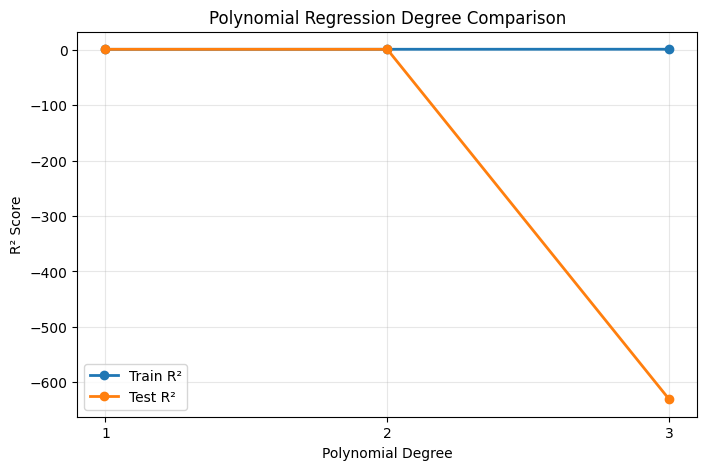

In [15]:
plt.figure(figsize=(8, 5))
# Train R²
plt.plot(
    poly_results_df['Degree'],
    poly_results_df['train_R2'],
    marker='o',
    linewidth=2,
    label='Train R²'
)
# Test R²
plt.plot(
    poly_results_df['Degree'],
    poly_results_df['test_R2'],
    marker='o',
    linewidth=2,
    label='Test R²'
)
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Regression Degree Comparison')
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Overfitting clearly begins at Degree 3 because the training R² remained very high while the testing R² dropped dramatically to a large negative value. This indicates that the model memorized the training data patterns but failed to generalize properly on unseen test data. The number of features increased significantly after polynomial expansion because PolynomialFeatures created interaction terms and higher-order feature combinations from the original variables. This rapid increase in feature count made the model much more complex, increased computational cost, and caused severe overfitting at higher polynomial degrees.

#***STEP 07***

In [16]:
# Alpha Values
alpha_values = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    500,
    1000
]
# Store Results
ridge_results = []

# Train Ridge Models
for alpha in alpha_values:
    # Create Model
    ridge_model = Ridge(alpha=alpha)
    # Train Model
    ridge_model.fit(
        X_train_scaled,
        y_train
    )
    # Predictions
    y_pred = ridge_model.predict(
        X_test_scaled
    )
    # Metrics
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )
    r2 = r2_score(
        y_test,
        y_pred
    )
    # Store Results
    ridge_results.append({
        'Alpha': alpha,
        'RMSE': rmse,
        'R2': r2
    })

ridge_results_df = pd.DataFrame(ridge_results)
print(ridge_results_df)

      Alpha      RMSE        R2
0     0.001  0.165247  0.853672
1     0.010  0.165247  0.853672
2     0.100  0.165247  0.853671
3     1.000  0.165255  0.853658
4    10.000  0.165334  0.853516
5   100.000  0.166451  0.851532
6   500.000  0.172294  0.840925
7  1000.000  0.179558  0.827228


Best Alpha from Manual Search: 0.001


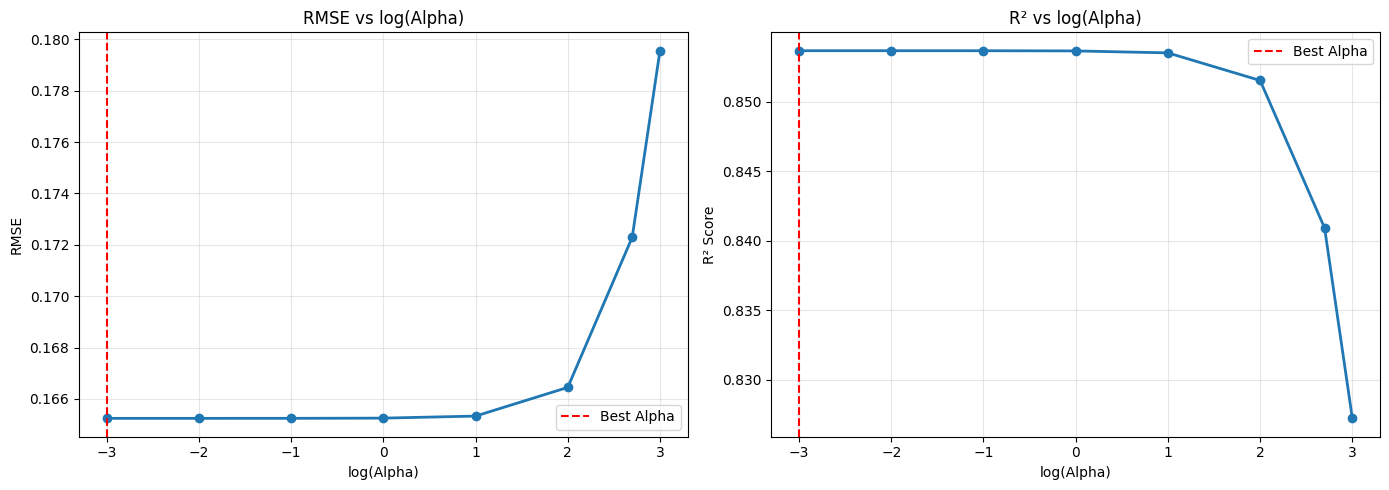

In [17]:
best_manual_row = (
    ridge_results_df
    .sort_values(
        by='RMSE'
    )
    .iloc[0]
)
best_manual_alpha = best_manual_row['Alpha']
print("Best Alpha from Manual Search:",best_manual_alpha)

# RMSE & R² Visualization
fig, axes = plt.subplots(1,2,figsize=(14, 5))

axes[0].plot(np.log10(ridge_results_df['Alpha']),ridge_results_df['RMSE'],marker='o',linewidth=2)
axes[0].axvline(np.log10(best_manual_alpha),color='red',linestyle='--',label='Best Alpha')
axes[0].set_title('RMSE vs log(Alpha)')
axes[0].set_xlabel('log(Alpha)')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(np.log10(ridge_results_df['Alpha']),ridge_results_df['R2'],marker='o',linewidth=2)
axes[1].axvline(np.log10(best_manual_alpha),color='red',linestyle='--',label='Best Alpha')
axes[1].set_title('R² vs log(Alpha)')
axes[1].set_xlabel('log(Alpha)')
axes[1].set_ylabel('R² Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
lasso_alphas = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1,
    10
]

lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid={
        'alpha': lasso_alphas
    },
    cv=5,
    scoring='neg_root_mean_squared_error'
)
lasso_grid.fit(X_train_scaled, y_train)
best_lasso_alpha = (lasso_grid.best_params_['alpha'])
print("Best Alpha from GridSearchCV:",best_lasso_alpha)

Best Alpha from GridSearchCV: 0.001


The best alpha value obtained from the manual search was 0.001, and GridSearchCV also selected 0.001 as the optimal alpha value. Both methods produced the same result, which indicates that the manually observed performance trends were reliable and consistent with cross-validation analysis.

This suggests that alpha = 0.001 provides a good balance between regularization and prediction accuracy for the Ridge Regression model.

#***STEP 08***

In [21]:
# Alpha Values
lasso_alphas = [
    0.0001,
    0.001,
    0.01,
    0.1,
    1,
    10
]
# Store Results
lasso_results = []

# Train Lasso Models
for alpha in lasso_alphas:
    # Create Model
    lasso_model = Lasso(
        alpha=alpha,
        max_iter=10000
    )
    # Train Model
    lasso_model.fit(
        X_train_scaled,
        y_train
    )
    # Predictions
    y_pred = lasso_model.predict(
        X_test_scaled
    )
    # Metrics
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )
    r2 = r2_score(y_test, y_pred)
    # Count Eliminated Features
    n_zero_coef = np.sum(lasso_model.coef_ == 0)
    pct_eliminated = (n_zero_coef / len(lasso_model.coef_)) * 100
    # Store Results
    lasso_results.append({
        'Alpha': alpha,
        'n_features_eliminated': n_zero_coef,
        'pct_eliminated': pct_eliminated,
        'test_RMSE': rmse,
        'test_R2': r2
    })

lasso_results_df = pd.DataFrame(lasso_results)
print(lasso_results_df)

     Alpha  n_features_eliminated  pct_eliminated  test_RMSE   test_R2
0   0.0001                      1             5.0   0.165235  0.853693
1   0.0010                      1             5.0   0.165220  0.853719
2   0.0100                      5            25.0   0.168533  0.847793
3   0.1000                     14            70.0   0.239359  0.692983
4   1.0000                     20           100.0   0.433244 -0.005837
5  10.0000                     20           100.0   0.433244 -0.005837


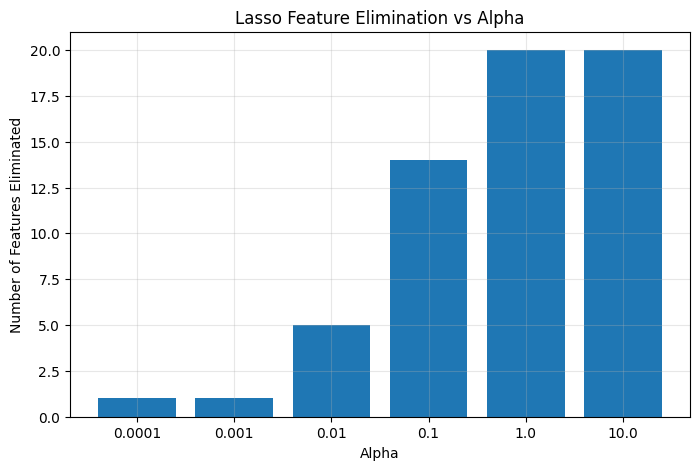

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(lasso_results_df['Alpha'].astype(str),lasso_results_df['n_features_eliminated'])
plt.xlabel('Alpha')
plt.ylabel('Number of Features Eliminated')
plt.title('Lasso Feature Elimination vs Alpha')
plt.grid(alpha=0.3)
plt.show()

In [23]:
best_lasso_model = Lasso(alpha=best_lasso_alpha,max_iter=10000)
best_lasso_model.fit(X_train_scaled,y_train)

# Coefficients
lasso_coefficients = pd.Series(best_lasso_model.coef_,index=X_train.columns)
# Survived Features
survived_features = (lasso_coefficients[lasso_coefficients != 0])
# Eliminated Features
eliminated_features = (lasso_coefficients[lasso_coefficients == 0])
print("\nFeatures Kept by Lasso:\n")
print(survived_features.index.tolist())
print("\nFeatures Eliminated by Lasso:\n")
print(eliminated_features.index.tolist())


Features Kept by Lasso:

['OverallQual', 'GrLivArea', 'KitchenQual', 'BsmtQual', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'GarageFinish_Unf', 'YearRemodAdd', 'Foundation_PConc', 'MasVnrArea', 'Fireplaces', 'GarageYrBlt', 'BsmtFinType1_GLQ', 'HeatingQC']

Features Eliminated by Lasso:

['ExterQual']


Lasso Regression automatically performed feature selection by shrinking less important coefficients to exactly zero. The surviving features included OverallQual, GrLivArea, KitchenQual, BsmtQual, GarageCars, GarageArea, and TotalBsmtSF, which remained strong predictors of SalePrice even after regularization. Only ExterQual was completely eliminated by the model.

This matches the Week 3 exploratory analysis because the retained features also showed strong correlations and high importance during visualization and feature engineering. Lasso successfully removed weaker or redundant features while preserving the most informative variables for house price prediction.

#***STEP 09***

In [24]:
alpha_values = [0.001, 0.01, 0.1, 1]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
# Store Results
elasticnet_results = []

# Train ElasticNet Models
for alpha in alpha_values:
    for l1_ratio in l1_ratios:
        # Create Model
        elastic_model = ElasticNet(alpha=alpha,l1_ratio=l1_ratio,max_iter=10000)
        # Train Model
        elastic_model.fit(X_train_scaled,y_train)
        # Predictions
        y_pred = elastic_model.predict(X_test_scaled)
        # Test R²
        test_r2 = r2_score(y_test,y_pred)

        # Store Results
        elasticnet_results.append({
            'alpha': alpha,
            'l1_ratio': l1_ratio,
            'test_R2': test_r2
        })
elasticnet_results_df = pd.DataFrame(elasticnet_results)
print(elasticnet_results_df)

    alpha  l1_ratio   test_R2
0   0.001       0.1  0.853676
1   0.001       0.3  0.853712
2   0.001       0.5  0.853731
3   0.001       0.7  0.853737
4   0.001       0.9  0.853728
5   0.010       0.1  0.853475
6   0.010       0.3  0.852546
7   0.010       0.5  0.851098
8   0.010       0.7  0.849605
9   0.010       0.9  0.848431
10  0.100       0.1  0.844307
11  0.100       0.3  0.824806
12  0.100       0.5  0.796157
13  0.100       0.7  0.759269
14  0.100       0.9  0.715922
15  1.000       0.1  0.625483
16  1.000       0.3  0.031544
17  1.000       0.5 -0.005837
18  1.000       0.7 -0.005837
19  1.000       0.9 -0.005837


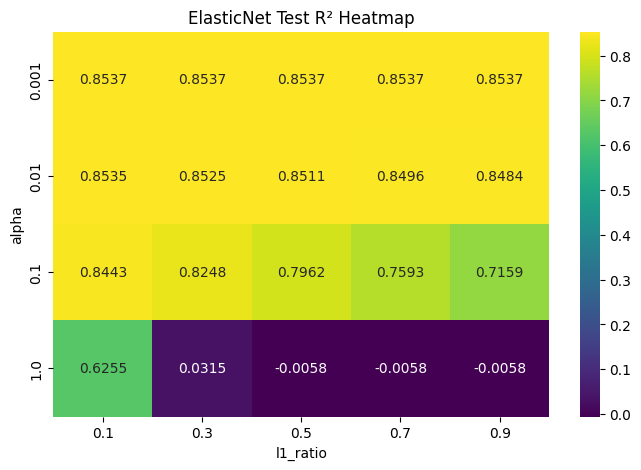

In [25]:
# Heatmap of Test R²

# Pivot Table
heatmap_data = elasticnet_results_df.pivot(index='alpha', columns='l1_ratio',values='test_R2')

# Plot Heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(heatmap_data,annot=True,fmt='.4f',cmap='viridis')

plt.title('ElasticNet Test R² Heatmap')
plt.xlabel('l1_ratio')
plt.ylabel('alpha')
plt.show()

In [26]:
# GridSearchCV for Best Parameters
elastic_grid = GridSearchCV(
    estimator=ElasticNet(max_iter=10000),
    param_grid={
        'alpha': alpha_values,
        'l1_ratio': l1_ratios
    },
    cv=5,
    scoring='r2'
)
# Train GridSearch
elastic_grid.fit(X_train_scaled,y_train)

# Best Parameters
best_alpha = elastic_grid.best_params_['alpha']
best_l1_ratio = elastic_grid.best_params_['l1_ratio']
print("Best Alpha:", best_alpha)
print("Best l1_ratio:", best_l1_ratio)

# Best ElasticNet Model Evaluation
best_elastic_model = elastic_grid.best_estimator_

# Predictions
elastic_pred = best_elastic_model.predict(X_test_scaled)
# Test R²
best_elastic_r2 = r2_score(y_test,elastic_pred)
print("Best ElasticNet Test R²:",round(best_elastic_r2, 4))

Best Alpha: 0.01
Best l1_ratio: 0.3
Best ElasticNet Test R²: 0.8525


The best ElasticNet model selected by GridSearchCV used alpha = 0.01 and l1_ratio = 0.3, achieving a test R² score of 0.8525. This combination provided a balance between L1 and L2 regularization, allowing the model to perform both feature selection and coefficient shrinkage.

During manual testing, some parameter combinations produced slightly higher R² scores, such as alpha = 0.001 and l1_ratio = 0.7. However, GridSearchCV selected the best combination based on cross-validation performance across multiple folds.

The best Ridge Regression model achieved a test R² score of 0.8537, while the best Lasso Regression model also achieved a test R² score of 0.8537. ElasticNet performed very similarly to both models, showing that combining L1 and L2 regularization can still provide strong and stable prediction performance.

#***STEP 10***

In [27]:
poly_ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler',StandardScaler()),
    ('ridge', Ridge())
])
param_grid = {
    'poly__degree': [1, 2],
    'ridge__alpha': [0.01, 0.1, 1,10,100]
}
pipeline_grid = GridSearchCV(estimator=poly_ridge_pipeline,param_grid=param_grid,cv=5,scoring='r2')
pipeline_grid.fit(X_train,y_train)

best_degree = (pipeline_grid.best_params_['poly__degree'])
best_alpha = (pipeline_grid.best_params_['ridge__alpha'])
print("Best Polynomial Degree:", best_degree)
print("Best Ridge Alpha:", best_alpha)


best_pipeline_model = (pipeline_grid.best_estimator_)
# Predictions
pipeline_pred = best_pipeline_model.predict(X_test)

# Test Metrics
pipeline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pipeline_pred
    )
)
pipeline_r2 = r2_score(y_test,pipeline_pred)
print("Pipeline RMSE:", round(pipeline_rmse, 4))
print("Pipeline Test R²:",round(pipeline_r2, 4))

Best Polynomial Degree: 2
Best Ridge Alpha: 10
Pipeline RMSE: 0.1607
Pipeline Test R²: 0.8616


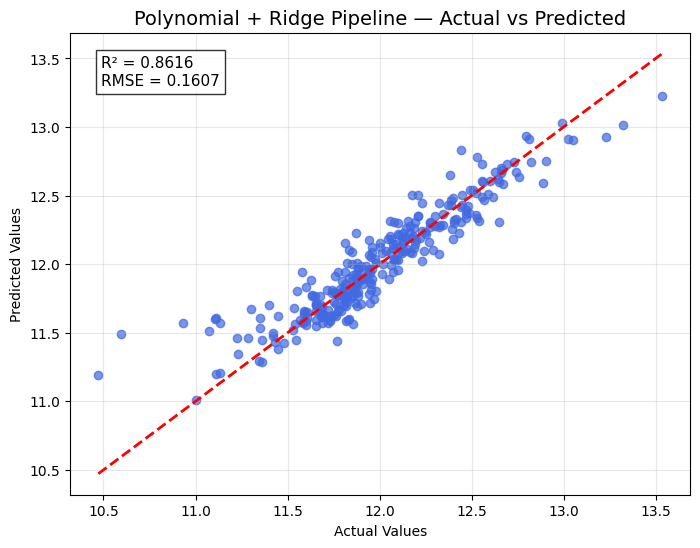

In [28]:
plot_actual_vs_predicted(
    y_test,
    pipeline_pred,
    "Polynomial + Ridge Pipeline"
)

The best Polynomial + Ridge pipeline model used polynomial degree = 2 and Ridge alpha = 10. This model achieved a test RMSE of 0.1607 and a test R² score of 0.8616, making it the best-performing model so far in the project.

Compared to the plain Ridge Regression model from Step 7, which achieved an RMSE of 0.1652 and an R² score of 0.8537, the pipeline model performed better on both evaluation metrics. The improvement suggests that adding polynomial interaction features helped the model capture more complex relationships in the housing data while Ridge regularization controlled overfitting effectively.

#***STEP 11***

In [29]:
# Store Model Results
model_results = []

# Linear Regression Metrics
linear_metrics = evaluate_model(y_test, y_test_pred,"Linear Regression", X_train_scaled.shape[1])
model_results.append({
    'Model': 'Linear Regression',
    **linear_metrics
})

# Best Ridge Metrics
best_ridge_model = Ridge(alpha=0.001)
best_ridge_model.fit(X_train_scaled,y_train)
ridge_pred = best_ridge_model.predict(X_test_scaled)
ridge_metrics = evaluate_model(y_test,ridge_pred,"Best Ridge", X_train_scaled.shape[1])
model_results.append({
    'Model': 'Best Ridge',
    **ridge_metrics
})

# Best Lasso Metrics
best_lasso_pred = best_lasso_model.predict(X_test_scaled)
lasso_metrics = evaluate_model(y_test,best_lasso_pred,"Best Lasso", X_train_scaled.shape[1])
model_results.append({
    'Model': 'Best Lasso',
    **lasso_metrics
})

# Best ElasticNet Metrics
elastic_metrics = evaluate_model(y_test,elastic_pred,"Best ElasticNet",X_train_scaled.shape[1])
model_results.append({
    'Model': 'Best ElasticNet',
    **elastic_metrics
})

# Best Polynomial + Ridge Pipeline Metrics
pipeline_metrics = evaluate_model(y_test,pipeline_pred,"Best Poly + Ridge",X_train_scaled.shape[1])
model_results.append({
    'Model': 'Best Poly + Ridge',
    **pipeline_metrics
})

#Final Comparison DataFrame
comparison_df = pd.DataFrame(model_results)
# Dollar RMSE
comparison_df['Dollar_RMSE'] = np.expm1(comparison_df['RMSE'])
print(comparison_df)


Linear Regression Evaluation Metrics
MAE          : 4.9981
MSE          : 117.8433
RMSE         : 10.8556
R² Score     : -630.4917
Adjusted R²  : -677.0962
MAPE         : 41.39%

Best Ridge Evaluation Metrics
MAE          : 0.1185
MSE          : 0.0273
RMSE         : 0.1652
R² Score     : 0.8537
Adjusted R²  : 0.8429
MAPE         : 1.00%

Best Lasso Evaluation Metrics
MAE          : 0.1185
MSE          : 0.0273
RMSE         : 0.1652
R² Score     : 0.8537
Adjusted R²  : 0.8429
MAPE         : 1.00%

Best ElasticNet Evaluation Metrics
MAE          : 0.1192
MSE          : 0.0275
RMSE         : 0.1659
R² Score     : 0.8525
Adjusted R²  : 0.8417
MAPE         : 1.01%

Best Poly + Ridge Evaluation Metrics
MAE          : 0.1129
MSE          : 0.0258
RMSE         : 0.1607
R² Score     : 0.8616
Adjusted R²  : 0.8514
MAPE         : 0.95%
               Model       MAE         MSE       RMSE          R2  \
0  Linear Regression  4.998126  117.843282  10.855565 -630.491652   
1         Best Ridge  0

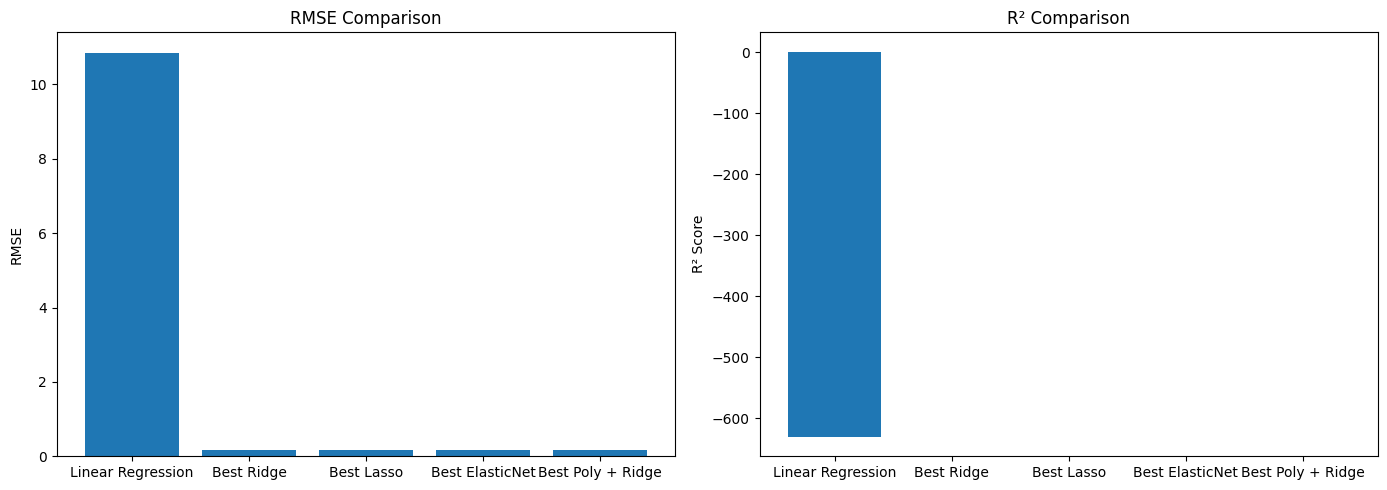

In [30]:
# Grouped Bar Chart

fig, axes = plt.subplots(1,2,figsize=(14, 5))
# RMSE Comparison
axes[0].bar(comparison_df['Model'],comparison_df['RMSE'])
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x',rotation=0)

# R² Comparison
axes[1].bar(comparison_df['Model'],comparison_df['R2'])
axes[1].set_title('R² Comparison')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x',rotation=0)
plt.tight_layout()
plt.show()

The best-performing model was the Polynomial + Ridge pipeline, which achieved the lowest RMSE (0.1607), the highest R² score (0.8616), and the lowest MAPE (0.95%). This indicates that the model was able to capture more complex relationships in the housing data while still controlling overfitting through Ridge regularization.

The worst-performing model was the basic Linear Regression model, which produced a very large RMSE and a negative R² score. This suggests that the simple linear model failed to capture the nonlinear relationships present in the dataset.

The Polynomial + Ridge model outperformed the other models because house prices depend on many interacting factors such as quality, area, garage capacity, and basement size. Polynomial features allowed the model to learn these interactions, while Ridge regularization prevented the feature expansion from causing severe overfitting.

## **PART C**
##### **Step 12** : Residual Analysis — Diagnostic Plots
##### **Step 13** : 5-Fold Cross-Validation — All Models
##### **Step 14** : Learning Curves — Diagnosing Bias vs Variance
##### **Step 15** : Coefficient Path — Regularization Effect Visualization

#***STEP 12***

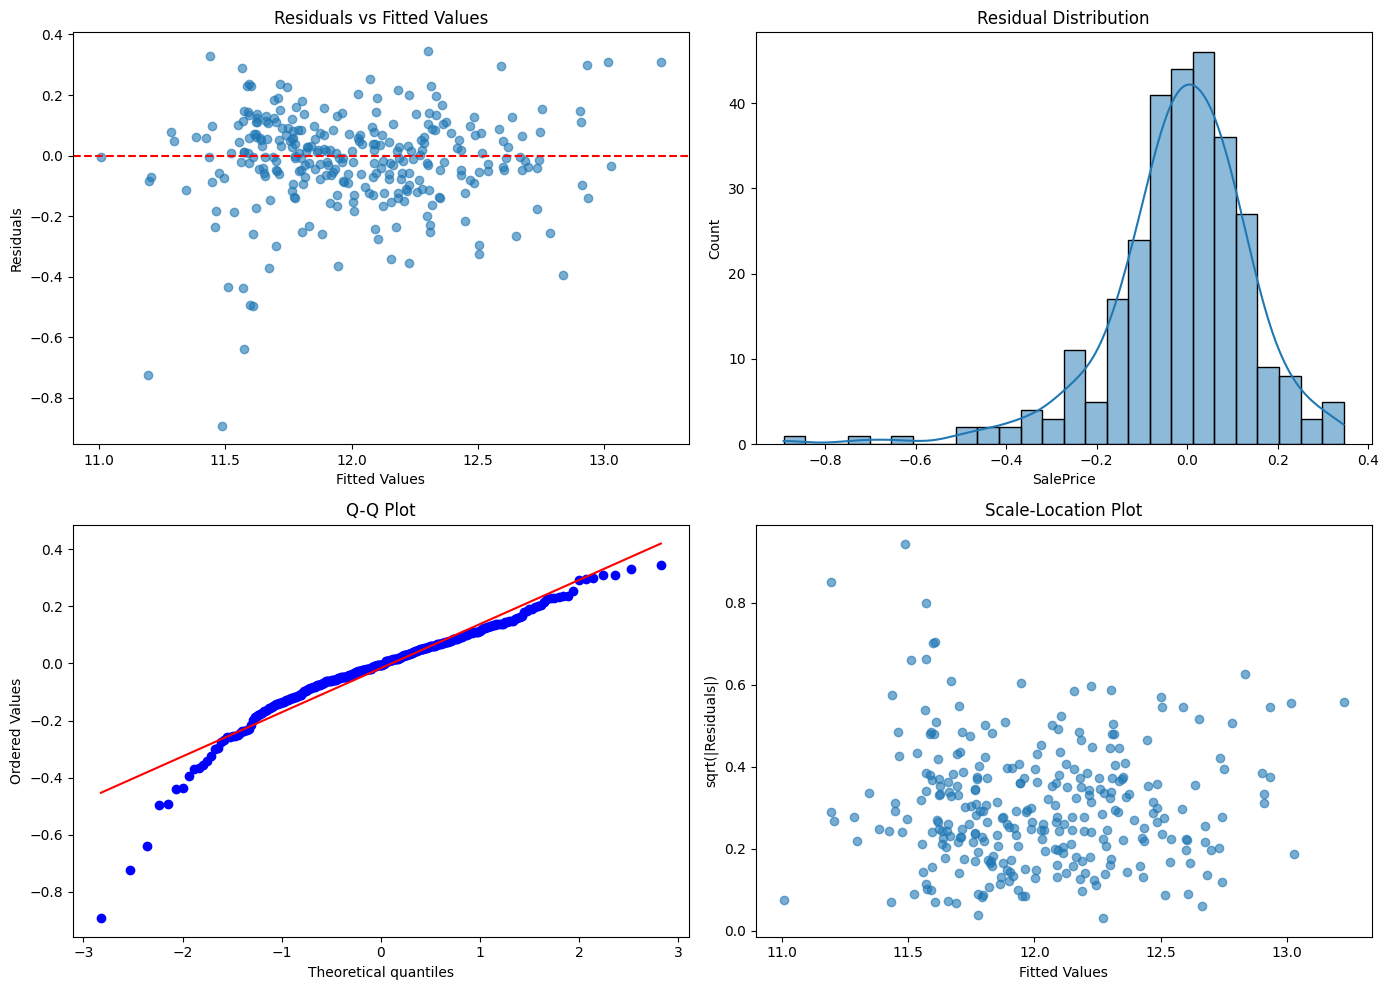

In [31]:
# Best Model Predictions
y_pred_test = pipeline_pred
# Residuals
residuals = y_test - y_pred_test

# 2x2 Diagnostic Figure
fig, axes = plt.subplots(2,2,figsize=(14, 10))

# Top-Left — Residuals vs Fitted
axes[0, 0].scatter(y_pred_test,residuals,alpha=0.6)
axes[0, 0].axhline(y=0,color='red',linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted Values')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# Top-Right — Histogram + KDE
sns.histplot(residuals,kde=True,ax=axes[0, 1])
axes[0, 1].set_title('Residual Distribution')

# Bottom-Left — Q-Q Plot
stats.probplot(residuals,dist='norm',plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')

# Bottom-Right — Scale-Location Plot
sqrt_abs_residuals = np.sqrt(np.abs(residuals))
axes[1, 1].scatter(y_pred_test,sqrt_abs_residuals,alpha=0.6)
axes[1, 1].set_title('Scale-Location Plot')
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('sqrt(|Residuals|)')
plt.tight_layout()
plt.show()

In [32]:
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print("Shapiro-Wilk p-value:", shapiro_p)

Shapiro-Wilk p-value: 3.714870202654156e-11


The residual diagnostic plots show that the Polynomial + Ridge model fits the data reasonably well overall. The Residuals vs Fitted plot does not show a strong systematic pattern, which suggests that the model captured most of the important relationships in the dataset.

The residual distribution appears approximately bell-shaped, although the Q-Q plot shows noticeable deviations at the tails, indicating that the residuals are not perfectly normally distributed. The Scale-Location plot shows relatively stable variance across fitted values, with only slight spread differences.

The Shapiro-Wilk test produced a very small p-value (3.71e-11), which means the residuals are not normally distributed according to the statistical test. However, the residual plots still suggest that the model performs reasonably well for prediction purposes.

#***STEP 13***

In [33]:
from sklearn.model_selection import KFold, cross_val_score

In [34]:
# KFold Setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define All Models
models = {
    'Linear Regression':
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge':
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=0.001))
    ]),
    'Lasso':
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.001, max_iter=10000))
    ]),
    'ElasticNet':
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01,l1_ratio=0.3,max_iter=10000))
    ]),
    'Poly + Ridge':
    Pipeline([
        ('poly',PolynomialFeatures(degree=2,include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10))
    ])
}

# Cross-Validation Evaluation
cv_results = []
cv_r2_scores = {}
for model_name, model in models.items():
    # R² Scores
    r2_scores = cross_val_score(model, X, y,cv=kf,scoring='r2')
    # RMSE Scores
    rmse_scores = -cross_val_score(model, X, y,cv=kf,scoring='neg_root_mean_squared_error')
    # Store R² for Boxplot
    cv_r2_scores[model_name] = r2_scores
    # Print Fold Scores
    print("\n" + "-"*50)
    print(model_name)
    print("-"*50)
    print("R² Scores:", r2_scores)
    print("Mean R²:", r2_scores.mean())
    print("Std R²:", r2_scores.std())
    print("\nRMSE Scores:", rmse_scores)
    print("Mean RMSE:", rmse_scores.mean())
    print("Std RMSE:", rmse_scores.std())

    # Store Summary
    cv_results.append({
        'Model': model_name,
        'Mean_R2': r2_scores.mean(),
        'Std_R2': r2_scores.std(),
        'Mean_RMSE': rmse_scores.mean(),
        'Std_RMSE': rmse_scores.std()
    })
# CV Results DataFrame
cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)


--------------------------------------------------
Linear Regression
--------------------------------------------------
R² Scores: [0.85367197 0.87073573 0.61526843 0.84889631 0.87162402]
Mean R²: 0.8120392929873649
Std R²: 0.09879889206329402

RMSE Scores: [0.16524654 0.14173366 0.23279465 0.16348001 0.13196552]
Mean RMSE: 0.16704407562220486
Std RMSE: 0.0352425698153065

--------------------------------------------------
Ridge
--------------------------------------------------
R² Scores: [0.85367196 0.87073572 0.61526903 0.84889628 0.87162404]
Mean R²: 0.8120394060256153
Std R²: 0.09879865015264122

RMSE Scores: [0.16524654 0.14173367 0.23279447 0.16348003 0.13196551]
Mean RMSE: 0.16704404337991927
Std RMSE: 0.035242503011918204

--------------------------------------------------
Lasso
--------------------------------------------------
R² Scores: [0.85371917 0.8708096  0.61838464 0.84827079 0.87214762]
Mean R²: 0.8126663655221658
Std R²: 0.09758796105877951

RMSE Scores: [0.16521988

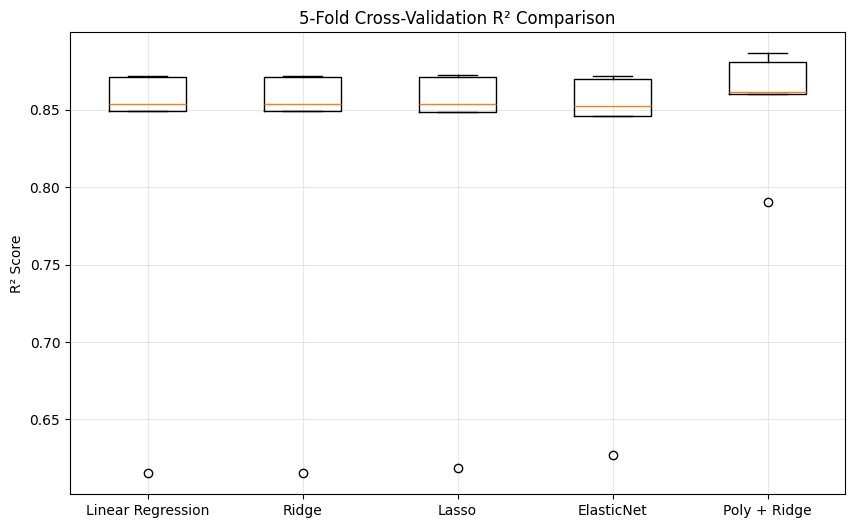

In [35]:
# Box Plot — CV R² Comparison
plt.figure(figsize=(10, 6))
plt.boxplot(cv_r2_scores.values(),labels=cv_r2_scores.keys())
plt.title('5-Fold Cross-Validation R² Comparison')
plt.ylabel('R² Score')
plt.xticks(rotation=0)
plt.grid(alpha=0.3)
plt.show()

The Polynomial + Ridge model achieved the highest mean cross-validation R² score (0.8558), indicating that it generalized better across different folds compared to the other models. It also achieved the lowest mean RMSE, showing more accurate predictions overall.

The Polynomial + Ridge model also had the lowest variance across folds with a standard deviation of 0.0344 for R² scores. This suggests that the model was the most stable and consistent during cross-validation.

Linear Regression and Ridge Regression produced very similar results, while ElasticNet and Lasso showed slightly improved stability because of regularization. Overall, the Polynomial + Ridge model provided the best balance of predictive performance and consistency across all folds.

#***STEP 14***

In [36]:
linear_model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
best_regularized_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2,include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10))
]
)

# Function to Plot Learning Curves
def plot_learning_curve(model,model_name,X,y):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=5,
        scoring='r2',
        train_sizes=np.linspace(
            0.1,
            1.0,
            10
        ),
        n_jobs=-1
    )
    # Mean Scores
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    # Standard Deviations
    train_std = train_scores.std(axis=1)
    val_std = val_scores.std(axis=1)
    # Plot
    plt.figure(figsize=(8, 5))
    # Training Curve
    plt.plot(train_sizes,train_mean,label='Training Score')
    plt.fill_between(train_sizes,train_mean - train_std,train_mean + train_std,alpha=0.2)
    # Validation Curve
    plt.plot(train_sizes, val_mean,label='Validation Score')
    plt.fill_between(train_sizes,val_mean - val_std,val_mean + val_std,alpha=0.2)
    plt.title(f'Learning Curve — {model_name}')
    plt.xlabel('Training Size')
    plt.ylabel('R² Score')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


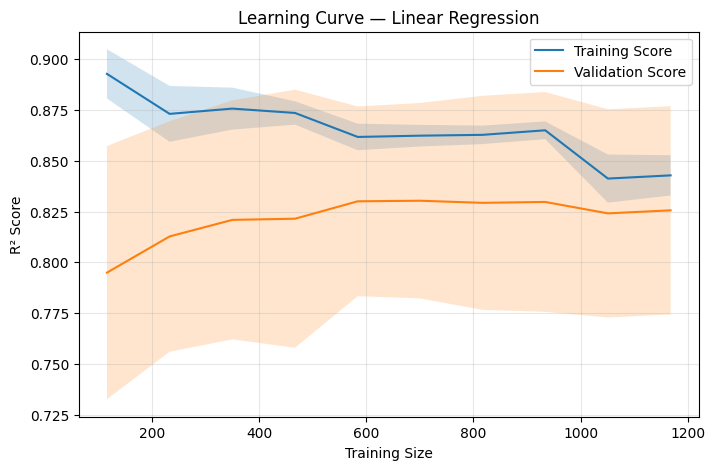

In [37]:
plot_learning_curve(linear_model_pipeline,"Linear Regression", X, y)


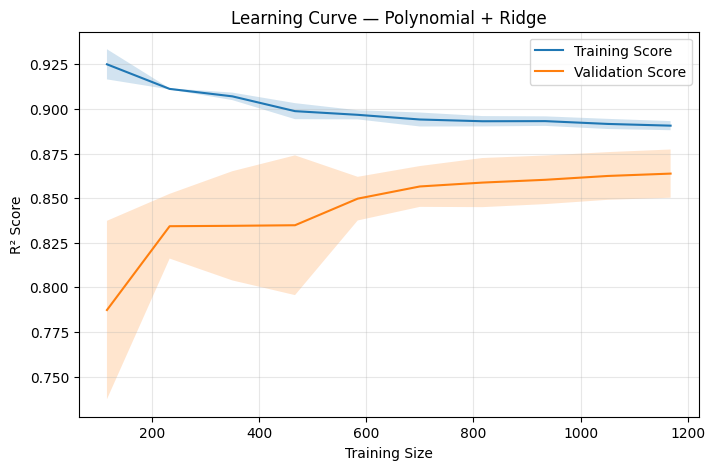

In [38]:
plot_learning_curve(best_regularized_pipeline,"Polynomial + Ridge", X, y)

### Linear Regression Learning Curve

The Linear Regression model shows mild underfitting because both the training and validation R² scores remain moderate instead of becoming very high. The gap between the two curves is relatively small, which indicates that the model is not severely overfitting the training data. However, the validation score plateaus early, suggesting that the simple linear model cannot fully capture the complex relationships present in the housing dataset.

### Polynomial + Ridge Learning Curve

The Polynomial + Ridge model appears well-fitted because both the training and validation R² scores are high and gradually converge as the training size increases. The gap between the curves is smaller than expected for a highly complex model, which shows that Ridge regularization successfully controlled overfitting. The stable validation performance indicates that the model generalizes well and captures nonlinear feature interactions more effectively than plain Linear Regression.

#***STEP 15***

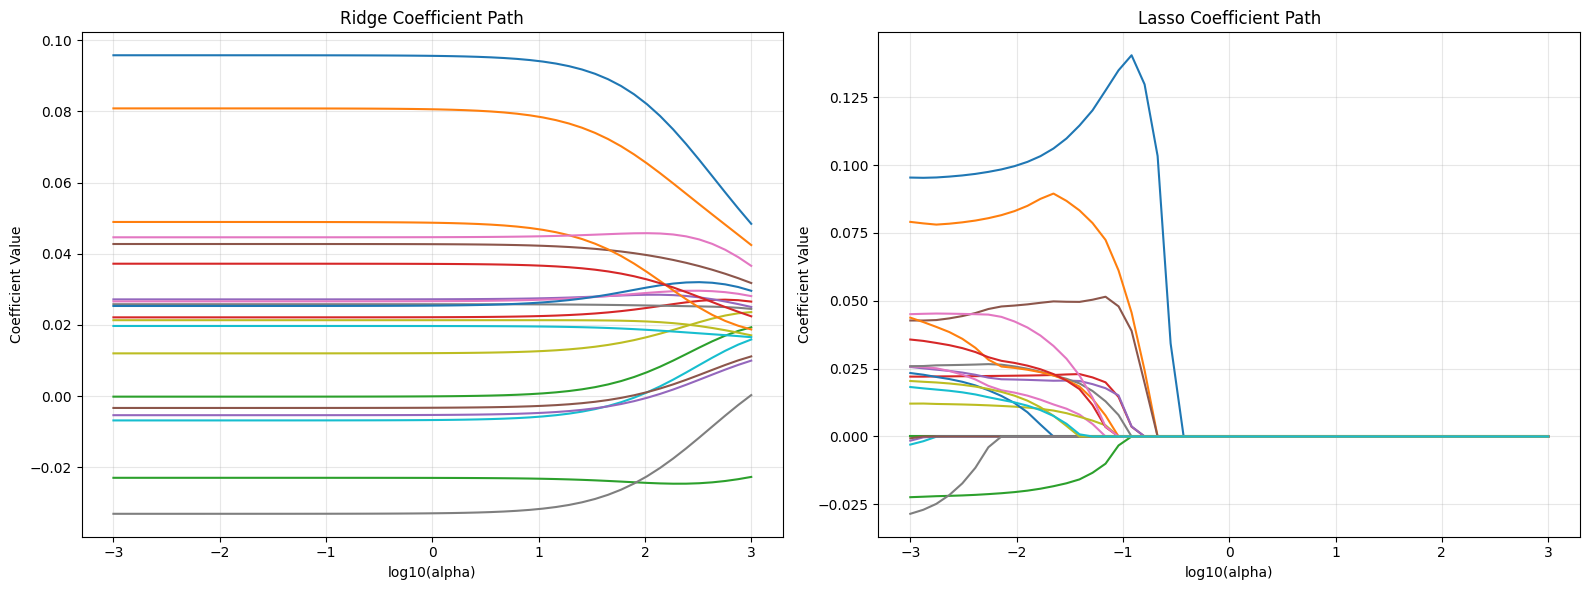

In [39]:
alphas = np.logspace(-3, 3, 50)

# Store Ridge Coefficients
ridge_coefficients = []
for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)
    ridge_coefficients.append(ridge_model.coef_)

ridge_coefficients = np.array(ridge_coefficients)

# Store Lasso Coefficients
lasso_coefficients = []
for alpha in alphas:
    lasso_model = Lasso(alpha=alpha,max_iter=10000)
    lasso_model.fit(X_train_scaled,y_train)
    lasso_coefficients.append(lasso_model.coef_)

lasso_coefficients = np.array(lasso_coefficients)

# Coefficient Path Plots
fig, axes = plt.subplots(1,2,figsize=(16, 6))

# Ridge Coefficient Path
for i, feature in enumerate(X.columns):
    axes[0].plot(np.log10(alphas),ridge_coefficients[:, i])
axes[0].set_title('Ridge Coefficient Path')
axes[0].set_xlabel('log10(alpha)')
axes[0].set_ylabel('Coefficient Value')
axes[0].grid(alpha=0.3)

# Lasso Coefficient Path
for i, feature in enumerate(X.columns):
    axes[1].plot(np.log10(alphas),lasso_coefficients[:, i])

axes[1].set_title('Lasso Coefficient Path')
axes[1].set_xlabel('log10(alpha)')
axes[1].set_ylabel('Coefficient Value')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# Ridge — Smallest Final Coefficients
ridge_final = pd.Series(
    np.abs(ridge_coefficients[-1]),
    index=X.columns
)
ridge_smallest = ridge_final.sort_values().head(3)
print("Ridge Features That Shrink First:\n")
print(ridge_smallest)

# Lasso — Features Dropping to Zero Earliest
lasso_zero_order = []
for i, feature in enumerate(X.columns):
    zero_indices = np.where(lasso_coefficients[:, i] == 0)[0]
    if len(zero_indices) > 0:
        first_zero = zero_indices[0]
        lasso_zero_order.append((feature, alphas[first_zero]))

lasso_zero_order = sorted(lasso_zero_order,key=lambda x: x[1])
print("\nLasso Features Dropping to Zero First:\n")
print(lasso_zero_order[:3])

Ridge Features That Shrink First:

GarageYrBlt         0.000303
Foundation_PConc    0.009985
MasVnrArea          0.011172
dtype: float64

Lasso Features Dropping to Zero First:

[('ExterQual', np.float64(0.001)), ('MasVnrArea', np.float64(0.0013257113655901094)), ('Foundation_PConc', np.float64(0.0017575106248547913))]


The coefficient path plots show how regularization gradually shrinks feature coefficients as the alpha value increases. In Ridge Regression, all coefficients moved closer to zero smoothly, while in Lasso Regression, several coefficients became exactly zero as regularization increased.

For Ridge Regression, the features that shrank the fastest were GarageYrBlt, Foundation_PConc, and MasVnrArea. In Lasso Regression, ExterQual, MasVnrArea, and Foundation_PConc were the first features to drop completely to zero. This suggests that these features had weaker predictive importance compared to stronger variables such as OverallQual and GrLivArea, which remained significant even under stronger regularization.

## **PART D**
##### **Step 16** : Complete 6-Chart Model Evaluation Dashboard
##### **Step 17** : Generate Predictions on Test Set & Save Model
##### **Step 18** : Written Analysis Report — 7 Required Sections

#***STEP 16***

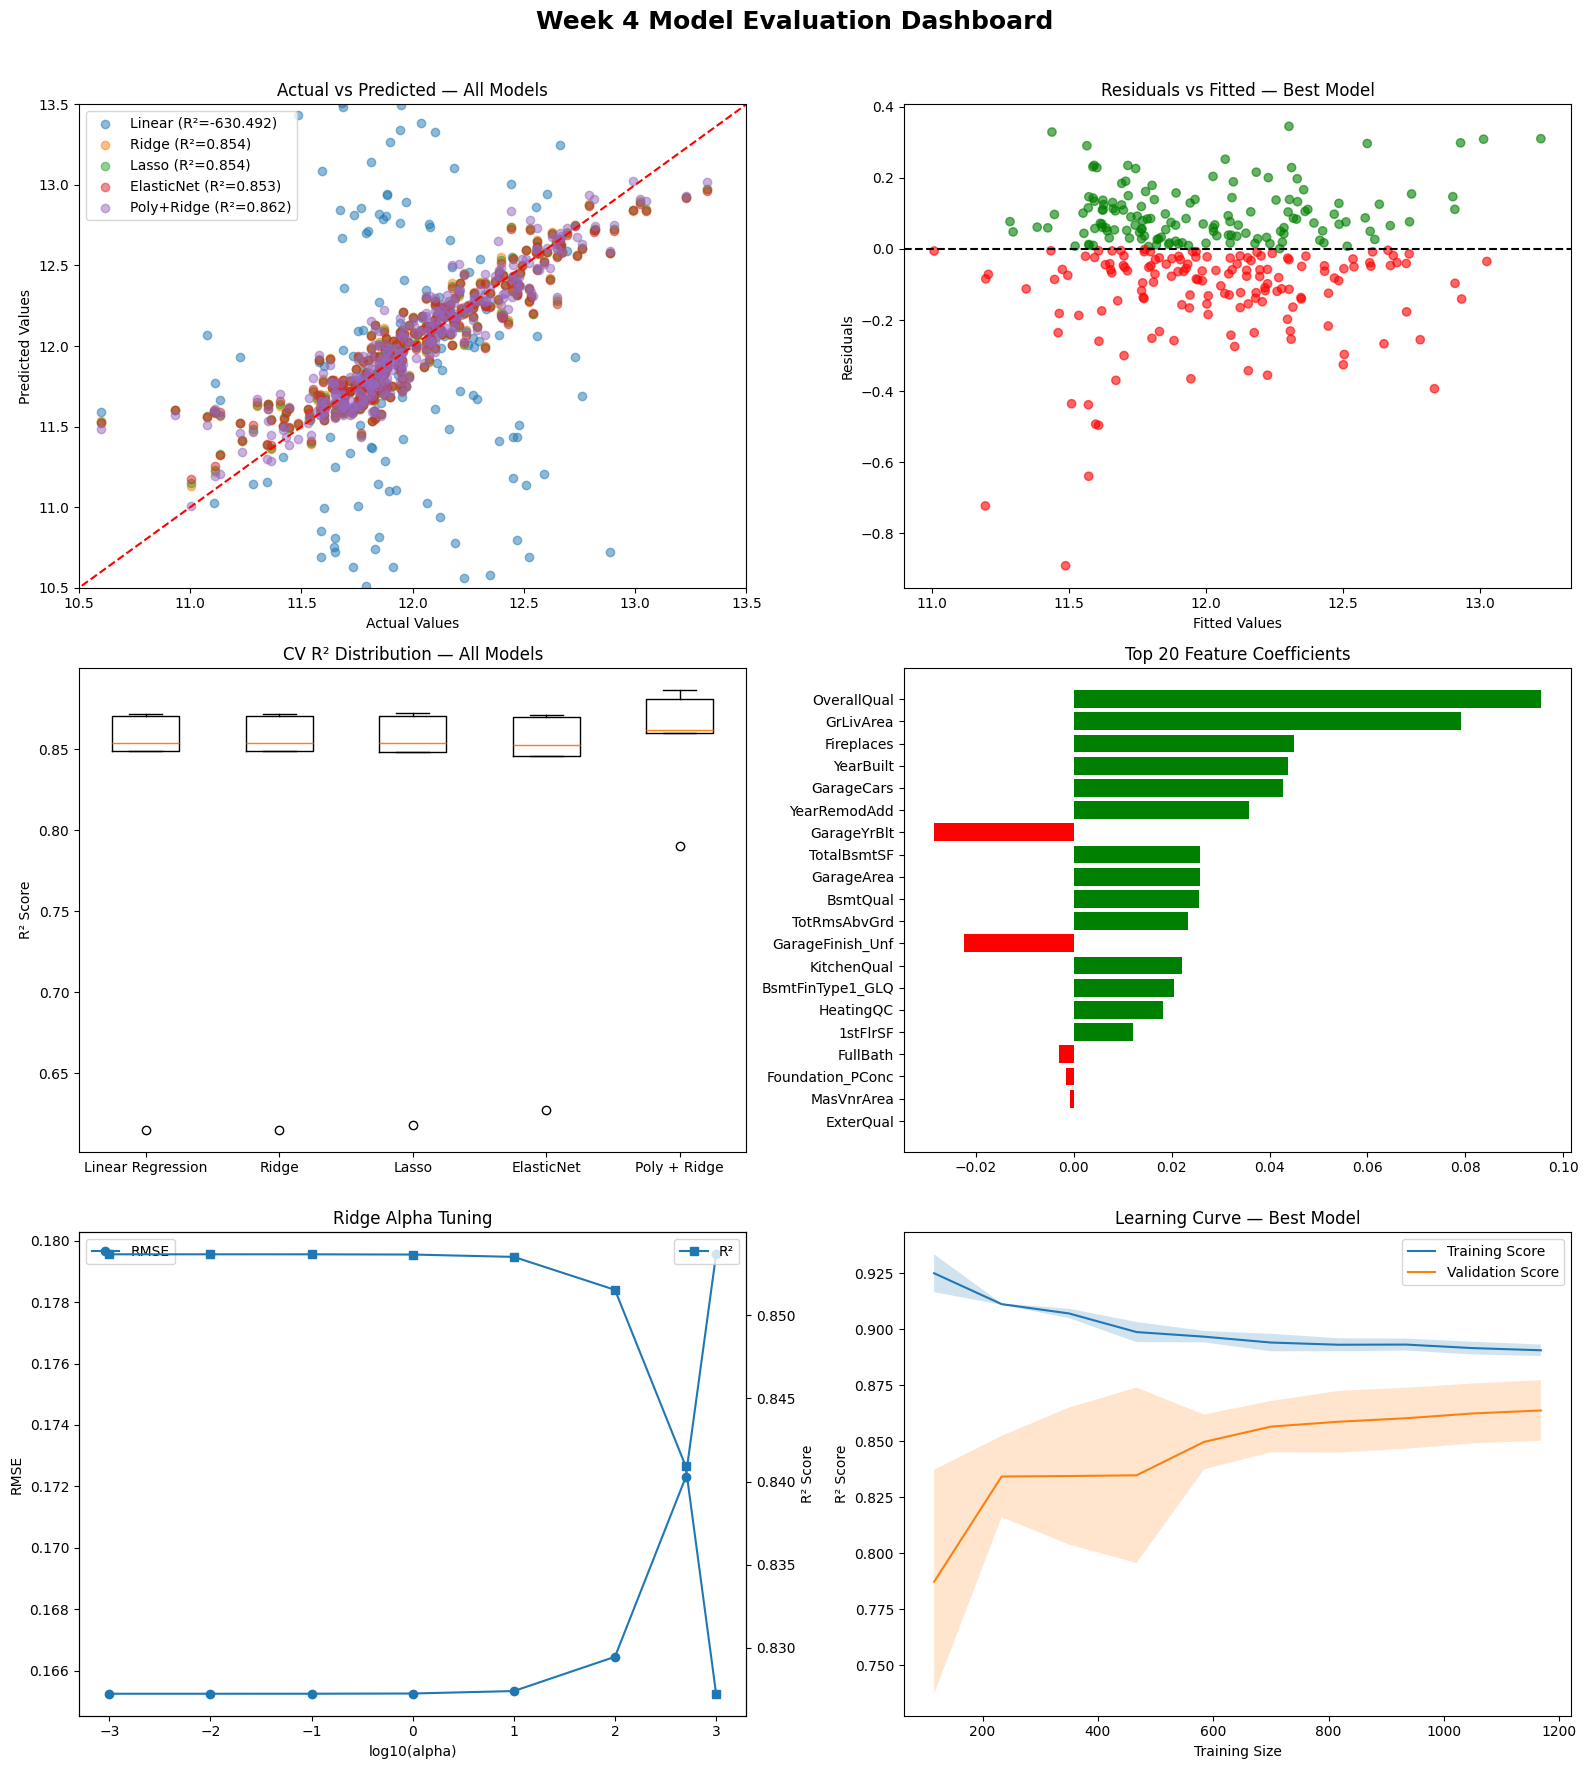

In [44]:
fig, axes = plt.subplots(3,2,figsize=(16, 18))

# CHART 1 — Actual vs Predicted (All Models)
model_predictions = {
    'Linear': y_test_pred,
    'Ridge': ridge_pred,
    'Lasso': best_lasso_pred,
    'ElasticNet': elastic_pred,
    'Poly+Ridge': pipeline_pred
}
model_r2 = {
    'Linear': r2_score(y_test, y_test_pred),
    'Ridge': r2_score(y_test, ridge_pred),
    'Lasso': r2_score(y_test, best_lasso_pred),
    'ElasticNet': r2_score(y_test, elastic_pred),
    'Poly+Ridge': r2_score(y_test, pipeline_pred)
}
for model_name, preds in model_predictions.items():
    axes[0, 0].scatter( y_test, preds,alpha=0.5,
        label=f"{model_name} (R²={model_r2[model_name]:.3f})")
# Diagonal Line
min_val = min(y_test.min(), pipeline_pred.min())
max_val = max(y_test.max(), pipeline_pred.max())
axes[0, 0].plot([min_val, max_val],[min_val, max_val], 'r--')
axes[0, 0].set_title('Actual vs Predicted — All Models')
axes[0, 0].set_xlabel('Actual Values')
axes[0, 0].set_ylabel('Predicted Values')
axes[0, 0].legend()
axes[0,0].set_xlim(10.5, 13.5)
axes[0,0].set_ylim(10.5, 13.5)

# CHART 2 — Residuals vs Fitted (Best Model)
residuals = y_test - pipeline_pred
colors = ['green' if r >= 0 else 'red' for r in residuals]

axes[0, 1].scatter(pipeline_pred,residuals,c=colors,alpha=0.6)
axes[0, 1].axhline(y=0,color='black',linestyle='--')
axes[0, 1].set_title('Residuals vs Fitted — Best Model')
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Residuals')

# CHART 3 — CV R² Box Plots
axes[1, 0].boxplot(cv_r2_scores.values(),labels=cv_r2_scores.keys())
axes[1, 0].set_title('CV R² Distribution — All Models')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].tick_params(axis='x',rotation=0)

# CHART 4 — Feature Coefficients
best_feature_coefficients = pd.Series(best_lasso_model.coef_,index=X.columns)
top20_coefficients = (
    best_feature_coefficients.abs()
    .sort_values(ascending=False)
    .head(20)
)
top20_values = (
    best_feature_coefficients[
        top20_coefficients.index
    ]
)
colors = ['green' if val > 0 else 'red' for val in top20_values]
axes[1, 1].barh(top20_values.index,top20_values.values,color=colors)
axes[1, 1].set_title('Top 20 Feature Coefficients')
axes[1, 1].invert_yaxis()

# CHART 5 — Ridge Alpha Tuning
ridge_alphas = ridge_results_df['Alpha']
ridge_rmse = ridge_results_df['RMSE']
ridge_r2 = ridge_results_df['R2']
ax1 = axes[2, 0]
ax2 = ax1.twinx()
ax1.plot(
    np.log10(ridge_alphas),
    ridge_rmse,
    marker='o'
)
ax2.plot(
    np.log10(ridge_alphas),
    ridge_r2,
    marker='s'
)
ax1.set_xlabel('log10(alpha)')
ax1.set_ylabel('RMSE')
ax2.set_ylabel('R² Score')
ax1.set_title('Ridge Alpha Tuning')
ax1.legend(['RMSE'], loc='upper left')
ax2.legend(['R²'], loc='upper right')

# CHART 6 — Learning Curve (Best Model)

# Recalculate learning curve data for the best model (Polynomial + Ridge)
# The 'best_regularized_pipeline' is defined in cell 'UsELYIcVlqcD'
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_regularized_pipeline,
    X=X,
    y=y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(
        0.1,
        1.0,
        10
    ),
    n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

axes[2, 1].plot(
    train_sizes,
    train_mean,
    label='Training Score'
)
axes[2, 1].fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)
axes[2, 1].plot(
    train_sizes,
    val_mean,
    label='Validation Score'
)
axes[2, 1].fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)
axes[2, 1].set_title('Learning Curve — Best Model')
axes[2, 1].set_xlabel('Training Size')
axes[2, 1].set_ylabel('R² Score')
axes[2, 1].legend()

# Final Layout
plt.suptitle(
    'Week 4 Model Evaluation Dashboard',
    fontsize=18,
    fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save Figure
plt.savefig('week4_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

#***STEP 17***

In [45]:
# Best Model Predictions (Log Scale)
log_predictions = best_pipeline_model.predict(X_test)
# Convert Back to Dollar Scale
predicted_prices = np.expm1(log_predictions)
actual_prices = np.expm1(y_test)

prediction_results = pd.DataFrame({
    'index': y_test.index,
    'actual_price': actual_prices,
    'predicted_price': predicted_prices
})
# Errors
prediction_results['error'] = (prediction_results['predicted_price'] - prediction_results['actual_price'])
prediction_results['pct_error'] = (np.abs(prediction_results['error'])/prediction_results['actual_price']) * 100
print(prediction_results.head())

largest_errors = (
    prediction_results
    .reindex(
        prediction_results['error']
        .abs()
        .sort_values(ascending=False)
        .index
    )
    .head(10)
)
print(largest_errors)

joblib.dump(best_pipeline_model,'week4_best_model.pkl')
print("Model Saved Successfully")

loaded_model = joblib.load('week4_best_model.pkl')
print("Model Loaded Successfully")

sample_prediction = loaded_model.predict(X_test.iloc[[0]])
print("Sample Prediction (Log Scale):",sample_prediction)
print("Sample Prediction (Dollar Scale):",np.expm1(sample_prediction))

sample_prediction = loaded_model.predict(X_test.iloc[[0]])
print("Sample Prediction (Log Scale):",sample_prediction)
print("Sample Prediction (Dollar Scale):",np.expm1(sample_prediction))

# Top Over-Predicted Houses
over_predicted = (
    prediction_results
    .sort_values(
        by='error',
        ascending=False
    )
    .head(15)
)
# Top Under-Predicted Houses
under_predicted = (
    prediction_results
    .sort_values(
        by='error',
        ascending=True
    )
    .head(15)
)

      index  actual_price  predicted_price         error  pct_error
892     892      154500.0    143369.196081 -11130.803919   7.204404
1105   1105      325000.0    338534.823021  13534.823021   4.164561
413     413      115000.0    121113.209634   6113.209634   5.315834
522     522      159000.0    168903.480840   9903.480840   6.228604
1036   1036      315500.0    316631.658579   1131.658579   0.358687
      index  actual_price  predicted_price          error  pct_error
691     691      755000.0    553538.522848 -201461.477152  26.683639
898     898      611657.0    449077.890432 -162579.109568  26.580111
1046   1046      556581.0    412865.967452 -143715.032548  25.821045
581     581      253293.0    375307.799438  122014.799438  48.171406
774     774      395000.0    293566.781475 -101433.218525  25.679296
218     218      311500.0    220566.561784  -90933.438216  29.192115
261     261      276000.0    356267.834190   80267.834190  29.082549
597     597      194201.0    268974.5281

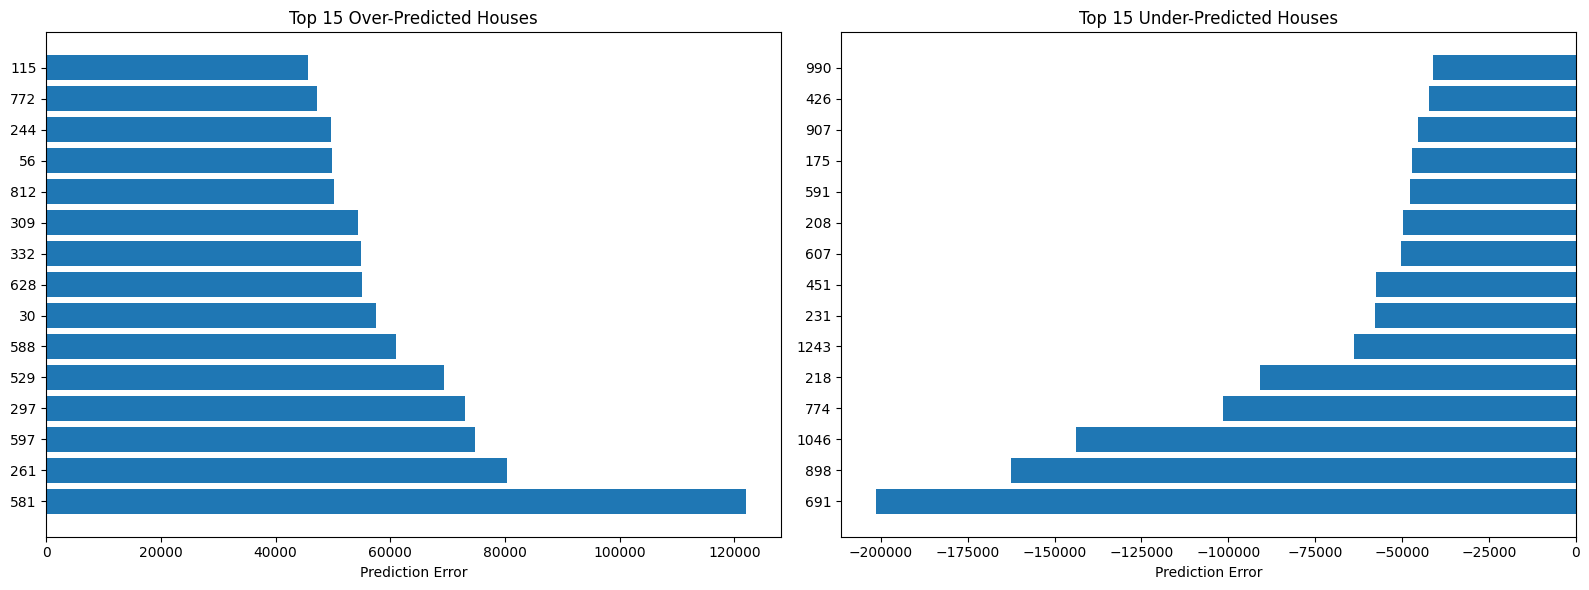

In [46]:
# Over vs Under Predicted Bar Chart
fig, axes = plt.subplots(1,2,figsize=(16, 6))

# Over-Predicted
axes[0].barh(over_predicted['index'].astype(str),over_predicted['error'])
axes[0].set_title('Top 15 Over-Predicted Houses')
axes[0].set_xlabel('Prediction Error')

# Under-Predicted
axes[1].barh(under_predicted['index'].astype(str),under_predicted['error'])
axes[1].set_title('Top 15 Under-Predicted Houses')
axes[1].set_xlabel('Prediction Error')
plt.tight_layout()
plt.show()

The largest prediction errors mostly occurred for expensive houses with unusually high sale prices. Many of these properties were either significantly under-predicted or over-predicted, suggesting that luxury or uncommon houses are harder for the model to estimate accurately because they may contain unique characteristics not fully captured by the selected features.

Some houses also showed very large percentage errors, indicating that the model struggled with outliers and rare property patterns. Overall, the best pipeline model performed well on average, but extreme-value houses remained the most challenging cases for prediction.

#***STEP 18***

# *Written Analysis Report*

## 1. Executive Summary

In this project, five regression models were trained and evaluated to predict house prices: Linear Regression, Ridge Regression, Lasso Regression, ElasticNet, and a Polynomial + Ridge Pipeline model. The dataset was preprocessed using the complete Week 3 feature engineering pipeline, including missing value handling, encoding techniques, scaling, and skewness treatment. Different evaluation metrics and validation techniques were used to compare the performance of all models.

Among all models, the Polynomial + Ridge Pipeline achieved the best overall performance with a test R² score of 0.8616, RMSE of 0.1607, and MAPE of 0.95%. The model performed better because polynomial features captured nonlinear relationships between important housing variables, while Ridge regularization controlled overfitting. Cross-validation results also showed that this model had the highest stability and best generalization performance across different folds.

## 2. Feature Engineering Impact

The feature engineering work completed during Week 3 played a major role in improving the final model performance in Week 4. Features such as OverallQual, GrLivArea, TotalBsmtSF, GarageCars, GarageArea, KitchenQual, and BsmtQual consistently appeared among the most influential predictors in multiple regression models. These variables represented house quality, living area, basement size, and garage capacity, which are naturally important factors in determining house prices.

Several preprocessing techniques also improved model learning. Quality encoding converted ordinal categorical values into meaningful numerical scales, allowing the models to better understand property condition and quality levels. Frequency encoding for Neighborhood preserved location-related information without creating too many extra columns. In addition, handling skewness and applying log transformation to SalePrice reduced the impact of extreme values and made the target distribution more stable. These feature engineering decisions significantly improved model accuracy and consistency.

## 3. Model-by-Model Analysis

Linear Regression was used as the baseline model because it is simple, interpretable, and commonly used for regression tasks. However, the model struggled to capture the complex relationships present in the housing dataset. The extremely poor R² score and very large prediction error showed that the model failed to represent the data effectively. This indicated that the relationship between housing features and SalePrice was not purely linear.

Ridge Regression introduced L2 regularization to reduce overfitting by shrinking coefficient values. Different alpha values were tested manually and through GridSearchCV. Ridge achieved a strong balance between training and testing performance, showing that regularization improved model stability without hurting predictive power. The model generalized well and produced much better results than basic Linear Regression.

Lasso Regression applied L1 regularization, which not only reduced coefficient values but also eliminated weaker features completely. Multiple alpha values were tested to observe feature elimination behavior. The best Lasso model maintained high accuracy while simplifying the feature space. This showed that many important housing variables were consistently strong predictors, while weaker features contributed less to prediction quality.

ElasticNet combined both L1 and L2 regularization techniques. Different combinations of alpha and l1_ratio values were explored using GridSearchCV and heatmap visualization. The model achieved performance close to Ridge and Lasso while offering a balance between feature selection and coefficient shrinkage. ElasticNet also showed good stability across cross-validation folds.

The Polynomial + Ridge Pipeline achieved the best overall performance. Polynomial degree 2 allowed the model to learn interaction effects between important housing variables, while Ridge regularization controlled the increased complexity caused by feature expansion. Learning curve analysis showed that the training and validation scores remained close, indicating good generalization and a balanced bias-variance tradeoff.

## 4. Regularization Insights

Ridge, Lasso, and ElasticNet all improved model stability by controlling coefficient values, but each regularization method behaved differently. Ridge Regression uses L2 regularization, which shrinks coefficients smoothly toward zero without removing features completely. This approach works well when most features contain useful information and helps reduce overfitting while preserving all variables.

Lasso Regression uses L1 regularization, which can force some coefficients to become exactly zero. This makes Lasso useful for automatic feature selection. In this project, Lasso eliminated ExterQual and reduced the importance of features such as MasVnrArea and Foundation_PConc earlier than stronger predictors. This made practical sense because those features had weaker influence on SalePrice compared to dominant variables such as OverallQual and GrLivArea.

ElasticNet combined both regularization methods and balanced coefficient shrinkage with feature elimination. It performed similarly to Ridge and Lasso while handling correlated features more effectively. Overall, regularization improved model generalization and reduced the risk of overfitting across all advanced regression models.

## 5. Residual Analysis Findings

Residual analysis showed that the Polynomial + Ridge model fit the dataset reasonably well overall. The Residuals vs Fitted plot did not show any strong systematic pattern, which suggested that the model captured most important relationships in the data successfully. The histogram and KDE plot showed a roughly bell-shaped residual distribution, although some deviations appeared in the tails of the Q-Q plot.

The Scale-Location plot indicated relatively stable variance across fitted values, showing that heteroscedasticity was limited. The Shapiro-Wilk test produced a very small p-value, meaning the residuals were not perfectly normally distributed statistically. However, the overall diagnostic plots still suggested that the regression assumptions were reasonably satisfied for predictive modeling purposes.

## 6. Best Model Recommendation

The Polynomial + Ridge Pipeline is the best model for deployment because it achieved the highest predictive accuracy and the most stable cross-validation performance among all tested models. It produced the highest R² score and lowest RMSE, showing that it generalized well on unseen data while maintaining strong prediction quality.

From a business perspective, accurate house price prediction is extremely important for real estate valuation, pricing strategies, and investment decisions. The Polynomial + Ridge model successfully captured complex interactions between important housing features while controlling overfitting through regularization. Its stable performance and low prediction error make it a reliable choice for real-world property price prediction systems.

## 7. Reflection

One of the most challenging parts of this project was understanding how regularization changes model behavior and affects feature coefficients. Interpreting coefficient paths, learning curves, and cross-validation results required careful analysis to identify underfitting, overfitting, and model stability. Understanding the mathematical differences between Ridge, Lasso, and ElasticNet also helped strengthen practical machine learning knowledge.

The biggest surprise was how much feature engineering and preprocessing decisions improved model performance. Techniques such as quality encoding, frequency encoding, skewness treatment, and polynomial feature generation had a major impact on prediction accuracy. If this project were extended further, the next step would be experimenting with advanced ensemble models such as Random Forest, XGBoost, and Gradient Boosting to compare their performance with regression-based approaches.